# Grocery Sales Database
Members : Madeline Agusalim, Jennifer Meisha, Kaitlyn Huang, Christabelle Gontani

1. Customer Segmentation via Clustering Analysis
2. Customer’s Next Purchase Category
3. Forecast Expected Sales Volume Per Category
4. Customer Churn Prediction


In [ ]:
import pandas as pd
customers = pd.read_csv('data/customers.csv')
products = pd.read_csv('data/products.csv')
categories = pd.read_csv('data/categories.csv')
countries = pd.read_csv('data/countries.csv')
cities = pd.read_csv('data/cities.csv')
sales = pd.read_csv('data/sales.csv')

In [ ]:
customers.head()

,CustomerID,FirstName,MiddleInitial,LastName,CityID,Address
0,1,Stefanie,Y,Frye,79,97 Oak Avenue
1,2,Sandy,T,Kirby,96,52 White First Freeway
2,3,Lee,T,Zhang,55,921 White Fabien Avenue
3,4,Regina,S,Avery,40,75 Old Avenue
4,5,Daniel,S,Mccann,2,283 South Green Hague Avenue


In [ ]:
products.head()

,ProductID,ProductName,Price,CategoryID,Class,ModifyDate,Resistant,IsAllergic,VitalityDays
0,1,Flour - Whole Wheat,74.2988,3,Medium,2018-02-16 08:21:49.190,Durable,Unknown,0.0
1,2,Cookie Chocolate Chip With,91.2329,3,Medium,2017-02-12 11:39:10.970,Unknown,Unknown,0.0
2,3,Onions - Cippolini,9.1379,9,Medium,2018-03-15 08:11:51.560,Weak,False,111.0
3,4,"Sauce - Gravy, Au Jus, Mix",54.3055,9,Medium,2017-07-16 00:46:28.880,Durable,Unknown,0.0
4,5,Artichokes - Jerusalem,65.4771,2,Low,2017-08-16 14:13:35.430,Durable,True,27.0


In [ ]:
categories.head()

,CategoryID,CategoryName
0,1,Confections
1,2,Shell fish
2,3,Cereals
3,4,Dairy
4,5,Beverages


In [ ]:
countries.head()

,CountryID,CountryName,CountryCode
0,1,Armenia,AN
1,2,Canada,FO
2,3,Belize,MK
3,4,Uganda,LV
4,5,Thailand,VI


In [ ]:
cities.head()

,CityID,CityName,Zipcode,CountryID
0,1,Dayton,80563,32
1,2,Buffalo,17420,32
2,3,Chicago,44751,32
3,4,Fremont,20641,32
4,5,Virginia Beach,62389,32


In [ ]:
sales.head()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber
0,1,6,27039,381,7,0.0,0.0,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G
1,2,16,25011,61,7,0.0,0.0,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8
2,3,13,94024,23,24,0.0,0.0,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0
3,4,8,73966,176,19,0.2,0.0,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE
4,5,10,32653,310,9,0.0,0.0,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3


In [ ]:
def quick_eda(df, name):
    print(f"TABLE : {name}")
    print(df.shape)
    print(df.dtypes)
    print(df.isna().sum())
    print(df.head())
    print("\n")

quick_eda(customers, "Customers")
quick_eda(products, "Products")
quick_eda(categories, "Categories")
quick_eda(sales, "Sales")
quick_eda(countries, "Countries")
quick_eda(cities, "Cities")


TABLE : Customers
(98759, 6)
CustomerID        int64
FirstName        object
MiddleInitial    object
LastName         object
CityID            int64
Address          object
dtype: object
CustomerID         0
FirstName          0
MiddleInitial    977
LastName           0
CityID             0
Address            0
dtype: int64
   CustomerID FirstName MiddleInitial LastName  CityID  \
0           1  Stefanie             Y     Frye      79   
1           2     Sandy             T    Kirby      96   
2           3       Lee             T    Zhang      55   
3           4    Regina             S    Avery      40   
4           5    Daniel             S   Mccann       2   

                        Address  
0                 97 Oak Avenue  
1        52 White First Freeway  
2       921 White Fabien Avenue  
3                 75 Old Avenue  
4  283 South Green Hague Avenue  


TABLE : Products
(452, 9)
ProductID         int64
ProductName      object
Price           float64
CategoryID        int

In [ ]:
# convert into string
sales['CustomerID'] = sales['CustomerID'].astype(str)
sales['ProductID'] = sales['ProductID'].astype(str)
customers['CustomerID'] = customers['CustomerID'].astype(str)
products['ProductID'] = products['ProductID'].astype(str)


In [ ]:
# Sales Data
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'], errors='coerce')
sales = sales.dropna(subset=['SalesDate']) # too many missing values

# Merge sales w products
sales = sales.merge(products[['ProductID', 'Price', 'CategoryID']], on='ProductID', how='left')
sales['TotalPrice'] = sales['Quantity'] * sales['Price'] # total price
sales.head()


,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Price,CategoryID
0,1,6,27039,381,7,0.0,309.6359,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,44.2337,1
1,2,16,25011,61,7,0.0,437.8220,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,62.5460,8
2,3,13,94024,23,24,0.0,1896.4416,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,79.0184,11
3,4,8,73966,176,19,0.2,1545.0173,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE,81.3167,6
4,5,10,32653,310,9,0.0,719.8020,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3,79.9780,9


In [ ]:
# merge dataset
df = sales.merge(customers, on='CustomerID', how='left') \
          .merge(cities, on='CityID', how='left') \
          .merge(countries, on='CountryID', how='left') \
          .merge(categories[['CategoryID','CategoryName']], on='CategoryID', how='left')

print(df.head())
df.isna().sum()


   SalesID  SalesPersonID CustomerID ProductID  Quantity  Discount  \
0        1              6      27039       381         7       0.0   
1        2             16      25011        61         7       0.0   
2        3             13      94024        23        24       0.0   
3        4              8      73966       176        19       0.2   
4        5             10      32653       310         9       0.0   

   TotalPrice               SalesDate     TransactionNumber    Price  ...  \
0    309.6359 2018-02-05 07:38:25.430  FQL4S94E4ME1EZFTG42G  44.2337  ...   
1    437.8220 2018-02-02 16:03:31.150  12UGLX40DJ1A5DTFBHB8  62.5460  ...   
2   1896.4416 2018-05-03 19:31:56.880  5DT8RCPL87KI5EORO7B0  79.0184  ...   
3   1545.0173 2018-04-07 14:43:55.420  R3DR9MLD5NR76VO17ULE  81.3167  ...   
4    719.8020 2018-02-12 15:37:03.940  4BGS0Z5OMAZ8NDAFHHP3  79.9780  ...   

   MiddleInitial LastName CityID                   Address     CityName  \
0              V    Green     54  826 Roc

SalesID                  0
SalesPersonID            0
CustomerID               0
ProductID                0
Quantity                 0
Discount                 0
TotalPrice               0
SalesDate                0
TransactionNumber        0
Price                    0
CategoryID               0
FirstName                0
MiddleInitial        66501
LastName                 0
CityID                   0
Address                  0
CityName                 0
Zipcode                  0
CountryID                0
CountryName              0
CountryCode              0
CategoryName             0
dtype: int64

In [ ]:
df = df.drop(columns=['FirstName','LastName','MiddleInitial','Address'])

In [ ]:
df['CountryCode'].unique()
df['CountryID'].unique() # only has American cities

array([32])

In [ ]:
list(df.columns)

['SalesID',
 'SalesPersonID',
 'CustomerID',
 'ProductID',
 'Quantity',
 'Discount',
 'TotalPrice',
 'SalesDate',
 'TransactionNumber',
 'Price',
 'CategoryID',
 'CityID',
 'CityName',
 'Zipcode',
 'CountryID',
 'CountryName',
 'CountryCode',
 'CategoryName']

In [ ]:
# drop country, cities
df_clean = df.copy()
df_clean = df_clean.drop(columns=['CountryID','CountryCode', 'CountryName', 'CityID', 'CityName', 'Zipcode'])
df_clean.head()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Price,CategoryID,CategoryName
0,1,6,27039,381,7,0.0,309.6359,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,44.2337,1,Confections
1,2,16,25011,61,7,0.0,437.8220,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,62.5460,8,Grain
2,3,13,94024,23,24,0.0,1896.4416,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,79.0184,11,Produce
3,4,8,73966,176,19,0.2,1545.0173,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE,81.3167,6,Seafood
4,5,10,32653,310,9,0.0,719.8020,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3,79.9780,9,Poultry


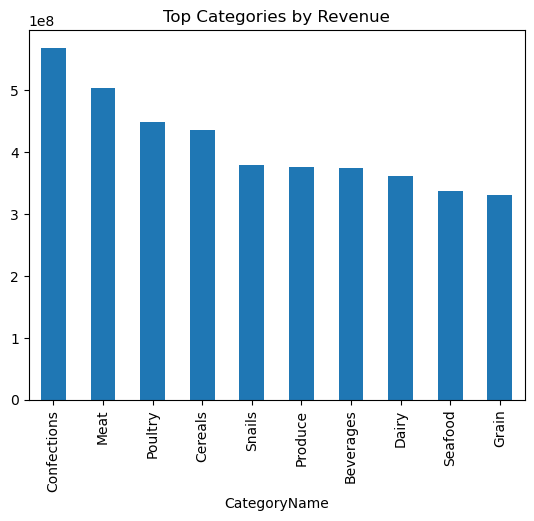

In [ ]:
import matplotlib.pyplot as plt

df_clean.groupby('CategoryName')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Categories by Revenue")
plt.show()


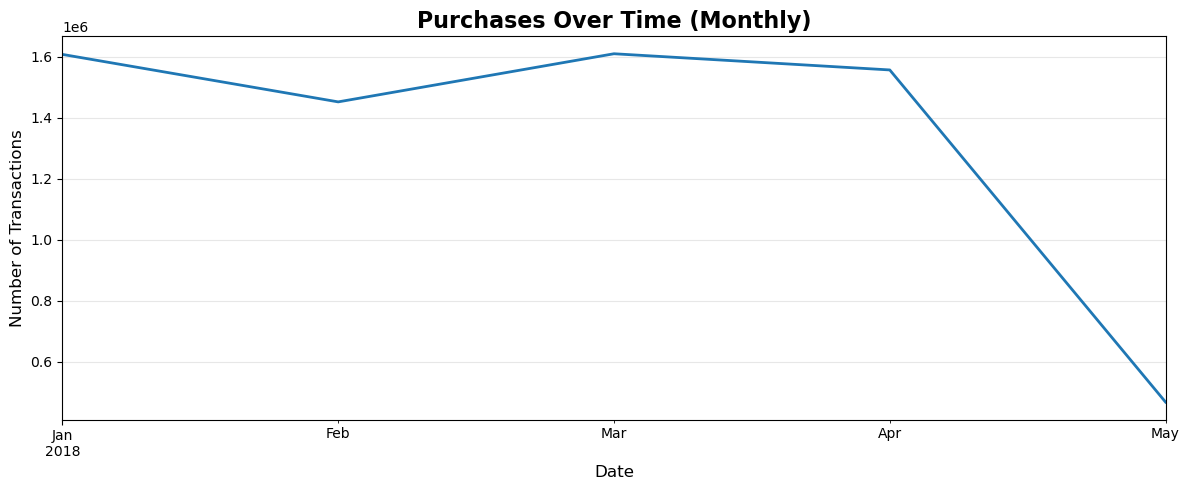

In [ ]:
# Monthly count
monthly = sales.set_index('SalesDate').resample('ME')['SalesID'].count()

plt.figure(figsize=(12,5))
monthly.plot(color="#1f77b4", linewidth=2)
plt.title("Purchases Over Time (Monthly)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Step 1 - Prep Data for Customer Clustering
df_model = df_clean.copy()
df_model.head()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Price,CategoryID,CategoryName
0,1,6,27039,381,7,0.0,309.6359,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,44.2337,1,Confections
1,2,16,25011,61,7,0.0,437.8220,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,62.5460,8,Grain
2,3,13,94024,23,24,0.0,1896.4416,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,79.0184,11,Produce
3,4,8,73966,176,19,0.2,1545.0173,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE,81.3167,6,Seafood
4,5,10,32653,310,9,0.0,719.8020,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3,79.9780,9,Poultry


In [ ]:
# Step 2 - Feature Engineering : Monetary Features

# Total Spend
total_spend = df_model.groupby('CustomerID')['TotalPrice'].sum().rename("TotalSpend")

# Number of Transactions
num_tx = df_model.groupby('CustomerID')['SalesID'].nunique().rename("NumTransactions")

# Avg Order Value
avg_order_value = (total_spend / num_tx).rename("AvgOrderValue")

# Spend per Category (Pivot Table)
cat_spend = df_model.pivot_table(
    index='CustomerID',
    columns='CategoryName',
    values='TotalPrice',
    aggfunc='sum',
    fill_value=0
)

# Spend concentration (% of spend in top categories)
top1 = cat_spend.max(axis=1) / cat_spend.sum(axis=1)
top2 = cat_spend.apply(lambda row: row.nlargest(2).sum(), axis=1) / cat_spend.sum(axis=1)

top1 = top1.rename("SpendTop1")
top2 = top2.rename("SpendTop2")

print(top1.shape, top2.shape)
cat_spend.head()



(98759,) (98759,)


CategoryName,Beverages,Cereals,Confections,Dairy,Grain,Meat,Poultry,Produce,Seafood,Shell fish,Snails
CustomerID,,,,,,,,,,,
1,214.7525,409.0242,186.5363,216.8964,554.0939,265.3783,324.8193,481.0646,138.9922,309.8128,145.2399
10,447.9441,354.8458,482.7720,212.6747,125.2388,183.5651,329.5593,145.4494,171.6894,231.1048,357.6170
100,439.2697,561.1025,230.5718,226.0839,318.2947,196.1861,281.0802,257.8025,153.7974,286.0351,209.6753
1000,200.2362,237.8124,439.4911,423.6170,602.8144,215.5599,244.7348,459.5462,676.5856,217.7384,250.1220
10000,430.3980,1088.1045,1507.8978,377.6115,753.6138,897.6228,689.7207,857.5140,534.9459,645.8082,919.5162


In [ ]:
# Step 3 - Feature Engineering : Frequency & Recency
import numpy as np

# Frequency = number of transactions
frequency = num_tx.rename("Frequency")

# Recency = days since last purchase
max_date = df_clean['SalesDate'].max()
recency = (max_date - df_clean.groupby('CustomerID')['SalesDate'].max()).dt.days.rename("RecencyDays")

# Avg Time Between Purchases
purchase_dates = df_clean.groupby('CustomerID')['SalesDate'].agg(list)

avg_time_between = purchase_dates.apply(
    lambda dates: np.mean(np.diff(sorted(dates))).days if len(dates) > 1 else np.nan
).rename("AvgTimeBetweenPurchases")

In [ ]:
# Step 4 - Feature Engineering :  Basket Composition

# Average basket size
avg_basket_size = df_clean.groupby('CustomerID')['Quantity'].mean().rename("AvgBasketSize")

# Category variety (# unique categories purchased)
cat_variety = df_clean.groupby('CustomerID')['CategoryName'].nunique().rename("CategoryVariety")

# Category mix (% of spend per category)
cat_mix = cat_spend.div(cat_spend.sum(axis=1), axis=0).add_prefix("CatMix_")

In [ ]:
# Step 5 - Build Customer-Level Feature Table

customer_features = (
    total_spend
    .to_frame()
    .join(avg_order_value)
    .join(frequency)
    .join(recency)
    .join(avg_time_between)
    .join(avg_basket_size)
    .join(cat_variety)
    .join(cat_spend.add_prefix("Spend_"))
    .join(cat_mix)
    .join(top1)
    .join(top2)
)

customer_features.head()

,TotalSpend,AvgOrderValue,Frequency,RecencyDays,AvgTimeBetweenPurchases,AvgBasketSize,CategoryVariety,Spend_Beverages,Spend_Cereals,Spend_Confections,...,CatMix_Dairy,CatMix_Grain,CatMix_Meat,CatMix_Poultry,CatMix_Produce,CatMix_Seafood,CatMix_Shell fish,CatMix_Snails,SpendTop1,SpendTop2
CustomerID,,,,,,,,,,,,,,,,,,,,,
1,3246.6104,51.533498,63,3,1,1.0,11,214.7525,409.0242,186.5363,...,0.066807,0.170668,0.081740,0.100049,0.148174,0.042811,0.095427,0.044736,0.170668,0.318843
10,3042.4604,55.317462,55,1,2,1.0,11,447.9441,354.8458,482.7720,...,0.069902,0.041164,0.060334,0.108320,0.047807,0.056431,0.075960,0.117542,0.158678,0.305909
100,3159.8992,55.436828,57,4,2,1.0,11,439.2697,561.1025,230.5718,...,0.071548,0.100729,0.062086,0.088952,0.081586,0.048672,0.090520,0.066355,0.177570,0.316584
1000,3968.2580,55.114694,72,0,1,1.0,11,200.2362,237.8124,439.4911,...,0.106751,0.151909,0.054321,0.061673,0.115806,0.170499,0.054870,0.063031,0.170499,0.322408
10000,8702.7534,150.047472,58,0,2,3.0,11,430.3980,1088.1045,1507.8978,...,0.043390,0.086595,0.103142,0.079253,0.098534,0.061469,0.074207,0.105658,0.173267,0.298297


In [ ]:
# Step 6 -  Scale Features for Clustering
from sklearn.preprocessing import StandardScaler

# Replace NaN or infinite values across whole table (safety check)
customer_features = customer_features.replace([np.inf, -np.inf], np.nan)
customer_features = customer_features.fillna(0)

# Scale
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_features)

scaled_features[:5]


array([[-1.6072223 , -1.64570386, -0.5782503 ,  0.82260324, -0.66810681,
        -1.66410074,  0.2046143 , -1.20999983, -1.19768972, -1.36523379,
        -1.19576054, -1.00560841, -1.29989177, -1.2606296 , -1.14820717,
        -1.2038024 , -1.10116802, -1.23590774, -0.47487754,  0.64093088,
        -1.51764091, -0.38686573,  2.48105841, -0.72028253, -0.03849489,
         1.68629082, -0.90591084,  0.73946336, -1.03983912, -0.06613169,
         0.13721394],
       [-1.61512369, -1.63548163, -1.5528171 , -0.23778434,  1.49055185,
        -1.66410074,  0.2046143 , -1.13104192, -1.21387846, -1.29260576,
        -1.1972265 , -1.16003915, -1.32191981, -1.2592151 , -1.26412067,
        -1.19178845, -1.13226966, -1.16496549,  1.59555732,  0.42233264,
         0.64338462, -0.30682678, -0.86258447, -1.20009638,  0.1624615 ,
        -0.9953868 , -0.53639865,  0.19017354,  0.80272152, -0.47494399,
        -0.19368643],
       [-1.61057836, -1.63515916, -1.3091754 ,  1.35279703,  1.49055185,
       

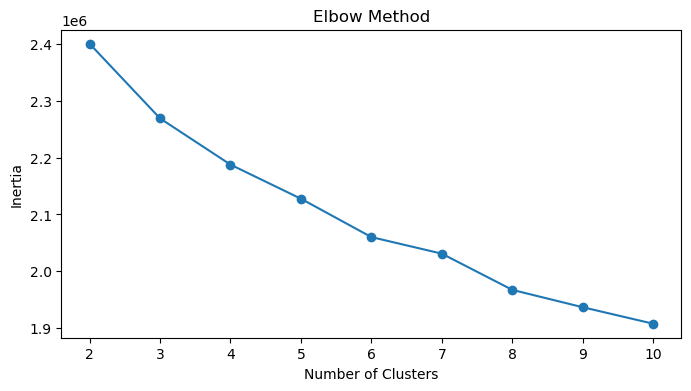

In [ ]:
# Step 7 - Clustering (KMeans, Elbow, Silhouette)

# elbow
from sklearn.cluster import KMeans

inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Silhouette={score:.4f}")


K=2, Silhouette=0.1927
K=3, Silhouette=0.1024
K=3, Silhouette=0.1024
K=4, Silhouette=0.0843
K=4, Silhouette=0.0843
K=5, Silhouette=0.0729
K=5, Silhouette=0.0729
K=6, Silhouette=0.0754
K=6, Silhouette=0.0754
K=7, Silhouette=0.0650
K=7, Silhouette=0.0650
K=8, Silhouette=0.0682
K=8, Silhouette=0.0682
K=9, Silhouette=0.0679
K=9, Silhouette=0.0679
K=10, Silhouette=0.0650
K=10, Silhouette=0.0650


In [ ]:
# Step 8 - K Means

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(scaled_features)

customer_features.head()


,TotalSpend,AvgOrderValue,Frequency,RecencyDays,AvgTimeBetweenPurchases,AvgBasketSize,CategoryVariety,Spend_Beverages,Spend_Cereals,Spend_Confections,...,CatMix_Grain,CatMix_Meat,CatMix_Poultry,CatMix_Produce,CatMix_Seafood,CatMix_Shell fish,CatMix_Snails,SpendTop1,SpendTop2,Cluster
CustomerID,,,,,,,,,,,,,,,,,,,,,
1,3246.6104,51.533498,63,3,1,1.0,11,214.7525,409.0242,186.5363,...,0.170668,0.081740,0.100049,0.148174,0.042811,0.095427,0.044736,0.170668,0.318843,2
10,3042.4604,55.317462,55,1,2,1.0,11,447.9441,354.8458,482.7720,...,0.041164,0.060334,0.108320,0.047807,0.056431,0.075960,0.117542,0.158678,0.305909,2
100,3159.8992,55.436828,57,4,2,1.0,11,439.2697,561.1025,230.5718,...,0.100729,0.062086,0.088952,0.081586,0.048672,0.090520,0.066355,0.177570,0.316584,2
1000,3968.2580,55.114694,72,0,1,1.0,11,200.2362,237.8124,439.4911,...,0.151909,0.054321,0.061673,0.115806,0.170499,0.054870,0.063031,0.170499,0.322408,2
10000,8702.7534,150.047472,58,0,2,3.0,11,430.3980,1088.1045,1507.8978,...,0.086595,0.103142,0.079253,0.098534,0.061469,0.074207,0.105658,0.173267,0.298297,2


In [ ]:
# Step 9 - Customer Personas
customer_features["Cluster"].value_counts() # cluster sizes


Cluster
2    32860
0    25703
3    24721
1    15475
Name: count, dtype: int64

In [ ]:
cluster_summary = customer_features.groupby("Cluster").mean()
cluster_summary


,TotalSpend,AvgOrderValue,Frequency,RecencyDays,AvgTimeBetweenPurchases,AvgBasketSize,CategoryVariety,Spend_Beverages,Spend_Cereals,Spend_Confections,...,CatMix_Dairy,CatMix_Grain,CatMix_Meat,CatMix_Poultry,CatMix_Produce,CatMix_Seafood,CatMix_Shell fish,CatMix_Snails,SpendTop1,SpendTop2
Cluster,,,,,,,,,,,,,,,,,,,,,
0,44422.040111,659.355833,68.188850,1.402755,1.278567,13.056430,10.983893,3919.891631,4316.077597,5013.742717,...,0.084561,0.079400,0.106555,0.100300,0.088058,0.080374,0.073898,0.088764,0.158440,0.294101
1,53618.419531,848.273647,63.763619,1.588821,1.521422,16.815873,10.886010,4093.236282,5381.905395,8865.763660,...,0.075874,0.063090,0.128947,0.104421,0.078372,0.068170,0.059225,0.079729,0.205665,0.358278
2,15899.688042,240.951898,66.779702,1.489501,1.352222,4.784358,10.956208,1345.655988,1578.120607,2072.059442,...,0.081516,0.074088,0.115001,0.101892,0.084787,0.075451,0.068797,0.085435,0.174195,0.315975
3,77979.103262,1102.716848,71.065814,1.353667,1.152219,21.473164,10.981675,6707.539839,7692.643190,9474.140985,...,0.082886,0.077387,0.110550,0.100930,0.086497,0.077890,0.071175,0.087098,0.164537,0.302268


In [ ]:
cat_cols = [c for c in customer_features.columns if c.startswith("Spend_")]
customer_features.groupby("Cluster")[cat_cols].mean()


,Spend_Beverages,Spend_Cereals,Spend_Confections,Spend_Dairy,Spend_Grain,Spend_Meat,Spend_Poultry,Spend_Produce,Spend_Seafood,Spend_Shell fish,Spend_Snails
Cluster,,,,,,,,,,,
0,3919.891631,4316.077597,5013.742717,3752.180141,3531.876243,4736.415655,4458.234353,3907.002830,3566.685409,3279.241517,3940.692019
1,4093.236282,5381.905395,8865.763660,4066.024823,3384.185370,6920.882688,5603.596263,4198.725233,3658.112947,3168.790974,4277.195897
2,1345.655988,1578.120607,2072.059442,1294.418735,1170.118588,1837.373293,1624.521466,1345.361304,1192.402697,1084.811277,1354.844647
3,6707.539839,7692.643190,9474.140985,6456.296740,6023.787266,8647.966419,7871.249585,6724.216408,6060.511287,5535.276221,6785.475322


In [ ]:
mix_cols = [c for c in customer_features.columns if c.startswith("CatMix_")]
customer_features.groupby("Cluster")[mix_cols].mean()


,CatMix_Beverages,CatMix_Cereals,CatMix_Confections,CatMix_Dairy,CatMix_Grain,CatMix_Meat,CatMix_Poultry,CatMix_Produce,CatMix_Seafood,CatMix_Shell fish,CatMix_Snails
Cluster,,,,,,,,,,,
0,0.088148,0.097131,0.112812,0.084561,0.079400,0.106555,0.100300,0.088058,0.080374,0.073898,0.088764
1,0.076464,0.100353,0.165355,0.075874,0.063090,0.128947,0.104421,0.078372,0.068170,0.059225,0.079729
2,0.084921,0.098785,0.129327,0.081516,0.074088,0.115001,0.101892,0.084787,0.075451,0.068797,0.085435
3,0.086155,0.098624,0.120809,0.082886,0.077387,0.110550,0.100930,0.086497,0.077890,0.071175,0.087098


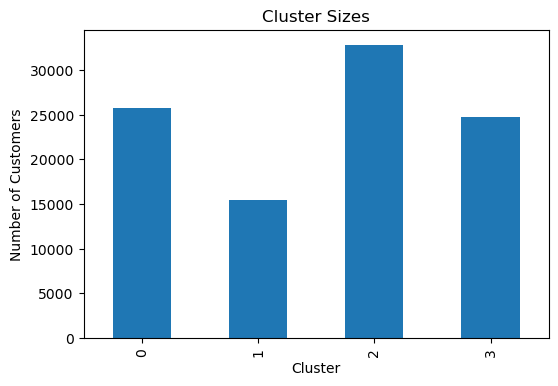

In [ ]:
customer_features["Cluster"].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


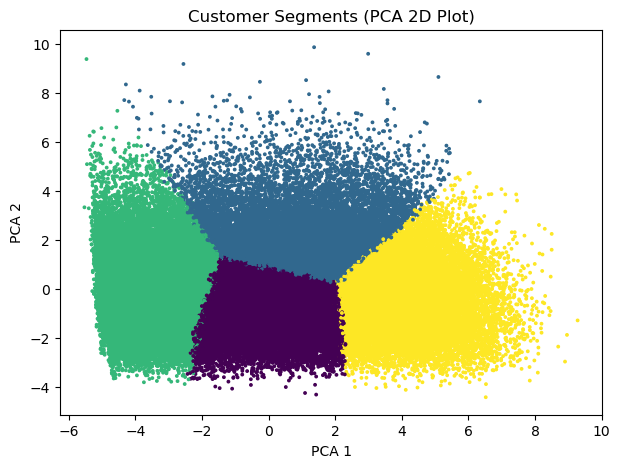

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_comp = pca.fit_transform(scaled_features)

plt.figure(figsize=(7,5))
plt.scatter(pca_comp[:,0], pca_comp[:,1], c=customer_features["Cluster"], cmap='viridis', s=3)
plt.title("Customer Segments (PCA 2D Plot)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


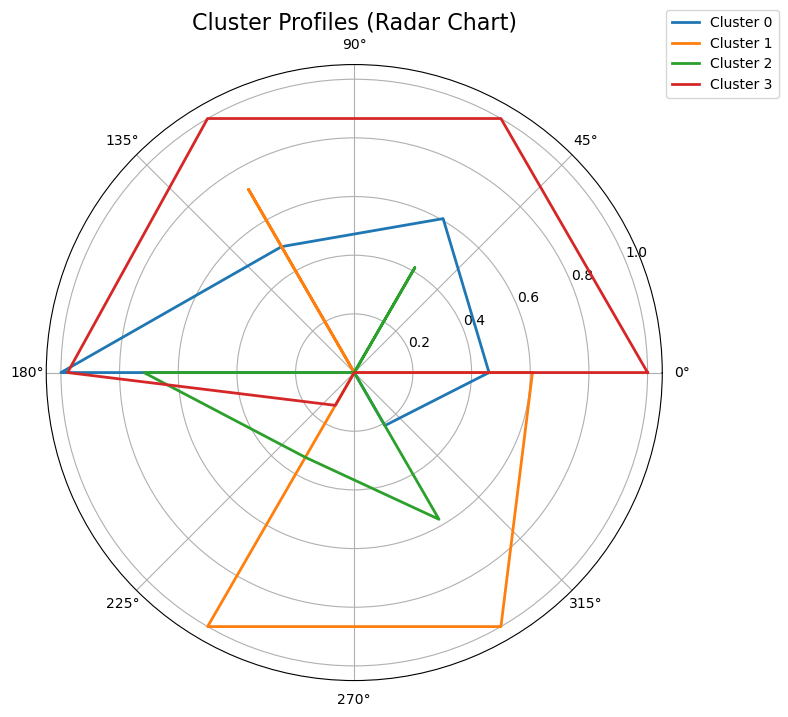

In [ ]:
key_features = ["TotalSpend", "Frequency", "AvgBasketSize",
                "CategoryVariety", "SpendTop1", "RecencyDays"]

cluster_means = customer_features.groupby("Cluster")[key_features].mean()

# Normalize 0-1 for radar plot
cluster_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Radar chart
labels = cluster_normalized.columns
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # loop back

plt.figure(figsize=(8,8))
for i, row in cluster_normalized.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Cluster {i}", linewidth=2)

plt.title("Cluster Profiles (Radar Chart)", fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()


### Customer Personas from Clustering Analysis

 **[NEED TO DO]: create the personas from results (e.g.): Cluster 0: Value-Conscious Regular Shoppers** (25,703 customers - 29%)

### Prediction Task 2: Forecast Expected Sales Volume Per Category

#### Objective
Predict how much of a category a given customer will buy next month using a cluster-then-predict workflow, where existing ClusterLabel is treated as a feature.

In [ ]:
# 1). build monthly aggregated df

customer_clusters = customer_features[['Cluster']].copy()
customer_clusters.columns = ['ClusterLabel']

df_pred = df_clean.merge(customer_clusters, left_on='CustomerID', right_index=True, how='left')

df_pred['YearMonth'] = df_pred['SalesDate'].dt.to_period('M')

# aggregate to CustomerID × CategoryID × YearMonth level
monthly_agg = df_pred.groupby(['CustomerID', 'CategoryName', 'YearMonth']).agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'SalesID': 'nunique',
    'Discount': 'mean',
    'Price': 'mean',
    'ClusterLabel': 'first'  # cluster is the same for each customer
}).reset_index()

monthly_agg.columns = ['CustomerID', 'CategoryName', 'YearMonth', 'Quantity', 'TotalSpend', 
                        'NumTransactions', 'AvgDiscount', 'AvgUnitPrice', 'ClusterLabel']

print(f"Monthly aggregated df shape: {monthly_agg.shape}")
print(f"Date range: {monthly_agg['YearMonth'].min()} to {monthly_agg['YearMonth'].max()}")
monthly_agg.head(10)

Monthly aggregated df shape: (3645792, 9)
Date range: 2018-01 to 2018-05


,CustomerID,CategoryName,YearMonth,Quantity,TotalSpend,NumTransactions,AvgDiscount,AvgUnitPrice,ClusterLabel
0,1,Beverages,2018-01,2,77.2577,2,0.1,38.628850,2
1,1,Beverages,2018-04,2,121.4492,2,0.1,60.724600,2
2,1,Beverages,2018-05,1,16.0456,1,0.0,16.045600,2
3,1,Cereals,2018-01,1,10.3722,1,0.0,10.372200,2
4,1,Cereals,2018-02,3,199.9744,3,0.0,66.658133,2
5,1,Cereals,2018-03,2,87.6368,2,0.0,43.818400,2
6,1,Cereals,2018-04,2,98.8263,2,0.1,49.413150,2
7,1,Cereals,2018-05,1,12.2145,1,0.1,12.214500,2
8,1,Confections,2018-02,2,105.4875,2,0.0,52.743750,2
9,1,Confections,2018-03,1,81.0488,1,0.2,81.048800,2


In [ ]:
# 2). create lag features & rolling window features

monthly_agg_sorted = monthly_agg.sort_values(['CustomerID', 'CategoryName', 'YearMonth']).reset_index(drop=True)

# lag features (per customer-category pair)
monthly_agg_sorted['Quantity_lag_1'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['Quantity'].shift(1)
)
monthly_agg_sorted['Quantity_lag_2'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['Quantity'].shift(2)
)
monthly_agg_sorted['Spend_lag_1'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['TotalSpend'].shift(1)
)
monthly_agg_sorted['NumTransactions_lag_1'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['NumTransactions'].shift(1)
)

# rolling window features (3-month window)
monthly_agg_sorted['Quantity_rolling_mean_3m'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['Quantity']
    .rolling(window=3, min_periods=1).mean().reset_index(drop=True)
)
monthly_agg_sorted['Quantity_rolling_std_3m'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['Quantity']
    .rolling(window=3, min_periods=1).std().reset_index(drop=True)
)

print(f"missing values per column:\n{monthly_agg_sorted.isnull().sum()}")

monthly_agg_sorted.fillna(0, inplace=True)
monthly_agg_sorted.head(10)

missing values per column:
CustomerID                        0
CategoryName                      0
YearMonth                         0
Quantity                          0
TotalSpend                        0
NumTransactions                   0
AvgDiscount                       0
AvgUnitPrice                      0
ClusterLabel                      0
Quantity_lag_1              1082279
Quantity_lag_2              2124515
Spend_lag_1                 1082279
NumTransactions_lag_1       1082279
Quantity_rolling_mean_3m          0
Quantity_rolling_std_3m     1082279
dtype: int64


,CustomerID,CategoryName,YearMonth,Quantity,TotalSpend,NumTransactions,AvgDiscount,AvgUnitPrice,ClusterLabel,Quantity_lag_1,Quantity_lag_2,Spend_lag_1,NumTransactions_lag_1,Quantity_rolling_mean_3m,Quantity_rolling_std_3m
0,1,Beverages,2018-01,2,77.2577,2,0.1,38.628850,2,0.0,0.0,0.0000,0.0,2.000000,0.000000
1,1,Beverages,2018-04,2,121.4492,2,0.1,60.724600,2,2.0,0.0,77.2577,2.0,2.000000,0.000000
2,1,Beverages,2018-05,1,16.0456,1,0.0,16.045600,2,2.0,2.0,121.4492,2.0,1.666667,0.577350
3,1,Cereals,2018-01,1,10.3722,1,0.0,10.372200,2,0.0,0.0,0.0000,0.0,1.000000,0.000000
4,1,Cereals,2018-02,3,199.9744,3,0.0,66.658133,2,1.0,0.0,10.3722,1.0,2.000000,1.414214
5,1,Cereals,2018-03,2,87.6368,2,0.0,43.818400,2,3.0,1.0,199.9744,3.0,2.000000,1.000000
6,1,Cereals,2018-04,2,98.8263,2,0.1,49.413150,2,2.0,3.0,87.6368,2.0,2.333333,0.577350
7,1,Cereals,2018-05,1,12.2145,1,0.1,12.214500,2,2.0,2.0,98.8263,2.0,1.666667,0.577350
8,1,Confections,2018-02,2,105.4875,2,0.0,52.743750,2,0.0,0.0,0.0000,0.0,2.000000,0.000000
9,1,Confections,2018-03,1,81.0488,1,0.2,81.048800,2,2.0,0.0,105.4875,2.0,1.500000,0.707107


In [ ]:
# 3). add seasonality features & create target var

monthly_agg_sorted['Month'] = monthly_agg_sorted['YearMonth'].dt.month
monthly_agg_sorted['Year'] = monthly_agg_sorted['YearMonth'].dt.year

# create cyclical month features (sin/cos)
monthly_agg_sorted['Month_sin'] = np.sin(2 * np.pi * monthly_agg_sorted['Month'] / 12)
monthly_agg_sorted['Month_cos'] = np.cos(2 * np.pi * monthly_agg_sorted['Month'] / 12)

# create the prediction target: Quantity_next_month
# shift quantity BACKWARD by -1 month (next month's quantity)
monthly_agg_sorted['Quantity_next_month'] = (
    monthly_agg_sorted.groupby(['CustomerID', 'CategoryName'])['Quantity'].shift(-1)
)

# drop rows with missing target (last month of data)
monthly_for_modeling = monthly_agg_sorted.dropna(subset=['Quantity_next_month']).copy()

print(f"df shape after adding seasonality and target: {monthly_for_modeling.shape}")
print(f"missing values per column:\n{monthly_for_modeling.isnull().sum()}")
monthly_for_modeling.head(10)

df shape after adding seasonality and target: (2563513, 20)
missing values per column:
CustomerID                  0
CategoryName                0
YearMonth                   0
Quantity                    0
TotalSpend                  0
NumTransactions             0
AvgDiscount                 0
AvgUnitPrice                0
ClusterLabel                0
Quantity_lag_1              0
Quantity_lag_2              0
Spend_lag_1                 0
NumTransactions_lag_1       0
Quantity_rolling_mean_3m    0
Quantity_rolling_std_3m     0
Month                       0
Year                        0
Month_sin                   0
Month_cos                   0
Quantity_next_month         0
dtype: int64


,CustomerID,CategoryName,YearMonth,Quantity,TotalSpend,NumTransactions,AvgDiscount,AvgUnitPrice,ClusterLabel,Quantity_lag_1,Quantity_lag_2,Spend_lag_1,NumTransactions_lag_1,Quantity_rolling_mean_3m,Quantity_rolling_std_3m,Month,Year,Month_sin,Month_cos,Quantity_next_month
0,1,Beverages,2018-01,2,77.2577,2,0.1,38.628850,2,0.0,0.0,0.0000,0.0,2.000000,0.000000,1,2018,0.500000,8.660254e-01,2.0
1,1,Beverages,2018-04,2,121.4492,2,0.1,60.724600,2,2.0,0.0,77.2577,2.0,2.000000,0.000000,4,2018,0.866025,-5.000000e-01,1.0
3,1,Cereals,2018-01,1,10.3722,1,0.0,10.372200,2,0.0,0.0,0.0000,0.0,1.000000,0.000000,1,2018,0.500000,8.660254e-01,3.0
4,1,Cereals,2018-02,3,199.9744,3,0.0,66.658133,2,1.0,0.0,10.3722,1.0,2.000000,1.414214,2,2018,0.866025,5.000000e-01,2.0
5,1,Cereals,2018-03,2,87.6368,2,0.0,43.818400,2,3.0,1.0,199.9744,3.0,2.000000,1.000000,3,2018,1.000000,6.123234e-17,2.0
6,1,Cereals,2018-04,2,98.8263,2,0.1,49.413150,2,2.0,3.0,87.6368,2.0,2.333333,0.577350,4,2018,0.866025,-5.000000e-01,1.0
8,1,Confections,2018-02,2,105.4875,2,0.0,52.743750,2,0.0,0.0,0.0000,0.0,2.000000,0.000000,2,2018,0.866025,5.000000e-01,1.0
10,1,Dairy,2018-02,2,85.7367,2,0.0,42.868350,2,0.0,0.0,0.0000,0.0,2.000000,0.000000,2,2018,0.866025,5.000000e-01,1.0
11,1,Dairy,2018-03,1,83.0110,1,0.0,83.011000,2,2.0,0.0,85.7367,2.0,1.500000,0.707107,3,2018,1.000000,6.123234e-17,1.0
13,1,Grain,2018-01,2,127.2362,2,0.1,63.618100,2,0.0,0.0,0.0000,0.0,2.000000,0.000000,1,2018,0.500000,8.660254e-01,2.0


In [ ]:
print(f"Date range: {monthly_for_modeling['YearMonth'].min()} to {monthly_for_modeling['YearMonth'].max()}")
#may dropped

Date range: 2018-01 to 2018-04


In [ ]:
# 4). time-based train/test split

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# get unique months
unique_months = sorted(monthly_for_modeling['YearMonth'].unique())

# Train: all except last 2 months
# Validation: second-last month
# Test: last month

train_val_split_idx = len(unique_months) - 2
val_test_split_idx = len(unique_months) - 1

train_months = unique_months[:train_val_split_idx]
val_months = [unique_months[train_val_split_idx]]
test_months = [unique_months[val_test_split_idx]]

train_df = monthly_for_modeling[monthly_for_modeling['YearMonth'].isin(train_months)].copy()
val_df = monthly_for_modeling[monthly_for_modeling['YearMonth'].isin(val_months)].copy()
test_df = monthly_for_modeling[monthly_for_modeling['YearMonth'].isin(test_months)].copy()

print(f"\nTrain set: {len(train_df)} rows (months: {train_months[0]} to {train_months[-1]})")
print(f"Val set: {len(val_df)} rows (month: {val_months[0]})")
print(f"Test set: {len(test_df)} rows (month: {test_months[0]})")


feature_cols = ['Quantity', 'TotalSpend', 'NumTransactions', 'AvgDiscount', 'AvgUnitPrice',
                'Quantity_lag_1', 'Quantity_lag_2', 'Spend_lag_1', 'NumTransactions_lag_1',
                'Quantity_rolling_mean_3m', 'Quantity_rolling_std_3m',
                'Month_sin', 'Month_cos', 'ClusterLabel']

target_col = 'Quantity_next_month'

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Train set: 1579365 rows (months: 2018-01 to 2018-02)
Val set: 696614 rows (month: 2018-03)
Test set: 287534 rows (month: 2018-04)

X_train shape: (1579365, 14)
X_val shape: (696614, 14)
X_test shape: (287534, 14)


In [ ]:
# Baseline XGBRegressor
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

cluster_id = 0
print(f"CLUSTER {int(cluster_id)}")

xgb_baseline = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)

xgb_baseline.fit(X_train, y_train)


y_val_pred_xgb_baseline = xgb_baseline.predict(X_val)

xgb_baseline_metrics = {
    "rmse": float(np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_baseline))),
    "mae": float(mean_absolute_error(y_val, y_val_pred_xgb_baseline)),
    "r2": float(r2_score(y_val, y_val_pred_xgb_baseline)),
}

print(f"Baseline XGB (Cluster {int(cluster_id)}) on Validation:")
print(f"  RMSE: {xgb_baseline_metrics['rmse']:.4f} | MAE: {xgb_baseline_metrics['mae']:.4f} | R²: {xgb_baseline_metrics['r2']:.4f}")


CLUSTER 0
Baseline XGB (Cluster 0) on Validation:
  RMSE: 15.4714 | MAE: 10.6203 | R²: 0.4269


In [ ]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    "n_estimators": randint(200, 500),        
    "learning_rate": uniform(0.02, 0.15),
    "max_depth": randint(4, 10),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(1, 7),
    "gamma": uniform(0, 1.5),                
}

xgb_base_estimator = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",     
    random_state=42,
    n_jobs=1,            
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base_estimator,
    param_distributions=xgb_param_dist,
    n_iter=15,              
    cv=2,         
    scoring="neg_mean_squared_error",
    n_jobs=1,          
    random_state=42,
    verbose=1,
)

xgb_random_search.fit(X_train, y_train)

print("Best hyperparameters:", xgb_random_search.best_params_)

Fitting 2 folds for each of 15 candidates, totalling 30 fits
Best hyperparameters: {'colsample_bytree': 0.7554563366576581, 'gamma': 1.4543769416468377, 'learning_rate': 0.13626992350416717, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 469, 'subsample': 0.9181815987569262}


In [ ]:
print(f"Best CV score (neg MSE): {xgb_random_search.best_score_:.4f}")

xgb_best = xgb_random_search.best_estimator_

y_val_pred_xgb_best = xgb_best.predict(X_val)

xgb_val_metrics = {
    "rmse": np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_best)),
    "mae": mean_absolute_error(y_val, y_val_pred_xgb_best),
    "r2": r2_score(y_val, y_val_pred_xgb_best),
}

print(f"Best XGB Model on Validation (Cluster {int(cluster_id)}):")
print(f"  RMSE: {xgb_val_metrics['rmse']:.4f} | MAE: {xgb_val_metrics['mae']:.4f} | R²: {xgb_val_metrics['r2']:.4f}")


Best CV score (neg MSE): -291.5154
Best XGB Model on Validation (Cluster 0):
  RMSE: 15.4565 | MAE: 10.6110 | R²: 0.4280


In [ ]:
# Retrain on train+val and Test evaluation
X_train_val_c = pd.concat([X_train, X_val], ignore_index=True)
y_train_val_c = pd.concat([y_train, y_val], ignore_index=True)

xgb_final = XGBRegressor(
    **xgb_random_search.best_params_,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2,
)

xgb_final.fit(X_train_val_c, y_train_val_c)

y_test_pred_xgb = xgb_final.predict(X_test)

xgb_test_metrics = {
    "rmse": float(np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))),
    "mae": float(mean_absolute_error(y_test, y_test_pred_xgb)),
    "r2": float(r2_score(y_test, y_test_pred_xgb)),
}

print("Final XGB Model on Test Set (Cluster 0):")
print(f"  RMSE: {xgb_test_metrics['rmse']:.4f} | MAE: {xgb_test_metrics['mae']:.4f} | R²: {xgb_test_metrics['r2']:.4f}")


Final XGB Model on Test Set (Cluster 0):
  RMSE: 12.7049 | MAE: 10.2166 | R²: -0.1598


### Prediction Task 3: Predict whether a customer will churn



#### Determine the Churn Definition
To create a meaningful churn label, we tested multiple RecencyDays thresholds (7, 10, 14, 20, 25, 30).  
Our goal was to find a cutoff that:

- Produces a realistic churn rate  
- Avoids extreme class imbalance  
- Preserves enough positive (churn) examples for modeling  

Based on the results, **Recency > 7 days** gives a churn rate of ~1–2%, which is balanced enough for training a predictive model in this dataset.


In [ ]:
for cutoff in [7, 10, 14, 20, 25, 30]:
    pct = (customer_features['RecencyDays'] > cutoff).mean()
    print(f"Cutoff {cutoff} days , churn rate = {pct:.3f}")

We define a customer as *churned* if they have not made a purchase in the last **7 days**.  
This produces a binary churn column we can use for supervised learning.

In [ ]:
customer_features['Churn'] = (customer_features['RecencyDays'] > 7).astype(int)
customer_features['Churn'].value_counts()

Before modeling, we analyze churn across the four customer clusters we created earlier.  
This reveals whether certain segments are more likely to churn and helps us interpret the final results.

In [ ]:
customer_features.groupby('Cluster')['Churn'].mean()


#### Train Global Churn Models

We train three different classification models on *all customers*:

- Logistic Regression  
- Random Forest  
- Gradient Boosting  

We remove RecencyDays before training to avoid data leakage, then evaluate all models using an 80/20 train–test split with stratification.

This global model represents our baseline approach.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Remove leakage
X = customer_features.drop(['Churn', 'RecencyDays'], axis=1)
y = customer_features['Churn']

# Global train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

global_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

global_results = {}

print("\n=== GLOBAL MODELS ===")
for name, model in global_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    global_results[name] = acc
    print(f"{name}: {acc:.4f}")


#### Train Cluster-Specific Churn Models
We also test a cluster-then-predict approach:

For each customer segment:
1. Select only the test-set customers in that cluster  
2. Train separate churn models (LR, RF, GB)  
3. Evaluate accuracy within the cluster  

This tests whether cluster-specific models outperform the global model, or whether one unified model is sufficient.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


cluster_model_results = {}

print("CLUSTER THEN PREDICT FOR CHURN")

for c in sorted(customer_features['Cluster'].unique()):
    print(f"\nCLUSTER {c}")

    mask = customer_features.index.isin(X_test.index)
    X_test_only = X_test.copy()
    X_test_only['Cluster'] = customer_features.loc[X_test.index, 'Cluster']

    X_c = X_test_only[X_test_only['Cluster'] == c].drop('Cluster', axis=1)
    y_c = y_test[X_test_only['Cluster'] == c]

    if len(X_c) < 50:
        print("Too few samples — skipping.")
        continue

    try:
        X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
            X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
        )
    except:
        X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
            X_c, y_c, test_size=0.2, random_state=42
        )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42)
    }

    cluster_model_results[c] = {}

    for name, model in models.items():
        model.fit(X_train_c, y_train_c)
        y_pred_c = model.predict(X_test_c)
        acc_c = accuracy_score(y_test_c, y_pred_c)
        cluster_model_results[c][name] = acc_c
        print(f"{name} Accuracy: {acc_c:.4f}")


### **Churn Prediction Conclusion**

Our churn model achieved **~98.5% accuracy**, showing that churn is highly predictable in this dataset.  
Churn rates were low across all segments (1–2%), and the model performed consistently well for every customer cluster.  
Cluster-specific models did **not** improve performance, confirming that a **single global model is sufficient** and generalizes effectively.

While the model provides useful insights, real-world deployment would require a longer time window, richer behavioral data, and a more realistic churn definition. 
